In [27]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rs = pd.read_csv("RecentSalescsv.csv")
ss = pd.read_csv("SalesSummary.csv")
rs.head(5)

,SaleID,CustomerID,ProductID,Quantity,Discount,SaleDate
0,3,40,58,1,0.21,2026-06-15
1,13,203,55,5,0.27,2026-05-20
2,22,127,26,3,0.28,2026-05-25
3,29,72,13,2,0.20,2026-06-15
4,35,199,47,1,0.22,2026-06-10


In [7]:
ss.head(5)

,Name,ProductName,Category,TotalAmount,SaleDate
0,Joan Chen,Desk Lamp Lite,Home,259.6500,2026-02-27
1,Nicolas Brown,Samsung Galaxy S24 Standard,Electronics,1151.3400,2025-10-18
2,Pamela Gregory,Scented Candle Pro,Home,56.0268,2026-06-15
3,Aaron Thompson,Men Slim Fit Shirt Pro,Clothing,68.3400,2026-05-04
4,Lisa Houston,Dell XPS Lite,Electronics,4478.3125,2025-09-03


In [11]:
rsd_type = rs.dtypes
ssd_type = ss.dtypes
rsn_unique = rs.nunique()
ssn_unique = ss.nunique()
pd.DataFrame({"RS Data Type":rsd_type, "RS unique numbers":rsn_unique})

,RS Data Type,RS unique numbers
SaleID,int64,74
CustomerID,int64,59
ProductID,int64,55
Quantity,int64,5
Discount,float64,28
SaleDate,object,26


In [12]:
pd.DataFrame({"SS Data Type":ssd_type,"SS unique numbers":ssn_unique})

,SS Data Type,SS unique numbers
Name,object,236
ProductName,object,100
Category,object,3
TotalAmount,float64,485
SaleDate,object,218


In [21]:
ss["Category"] = ss["Category"].astype('category')
pd.DataFrame({"SS Data Type":ss.dtypes})

,SS Data Type
Name,object
ProductName,object
Category,category
TotalAmount,float64
SaleDate,object


In [24]:
ss["SaleDate"] = ss["SaleDate"].astype("datetime64[ns]")
rs["SaleDate"] = rs["SaleDate"].astype("datetime64[ns]")
ss.dtypes

Name                   object
ProductName            object
Category             category
TotalAmount           float64
SaleDate       datetime64[ns]
dtype: object

In [25]:
rs.dtypes

SaleID                 int64
CustomerID             int64
ProductID              int64
Quantity               int64
Discount             float64
SaleDate      datetime64[ns]
dtype: object

In [28]:
rs_null = rs.isnull().sum()
ss_null = ss.isnull().sum()
rs_nratio = rs_null /rs.shape[0]
ss_nratio = ss_null / ss.shape[0]
pd.DataFrame({"RS Null":rs_null,"RS Null Ratio":rs_nratio})

,RS Null,RS Null Ratio
SaleID,0,0.0
CustomerID,0,0.0
ProductID,0,0.0
Quantity,0,0.0
Discount,0,0.0
SaleDate,0,0.0


In [29]:
pd.DataFrame({"SS Null":ss_null,"SS Null Ratio":ss_nratio})

,SS Null,SS Null Ratio
Name,0,0.0
ProductName,0,0.0
Category,0,0.0
TotalAmount,0,0.0
SaleDate,0,0.0


In [34]:
rs_dup = rs.duplicated().sum()
ss_dup = ss.duplicated().sum()
pd.DataFrame({"RS dup": [rs_dup], "SS dup": [ss_dup]})

,RS dup,SS dup
0,0,0


In [41]:
pr = pd.read_csv("Products.xls")
cus = pd.read_csv("Customers.xls")

In [46]:
print("Products columns:", pr.columns)
print("Customers columns:", cus.columns)

Products columns: Index(['ProductID', 'ProductName', 'Category', 'SubCategory', 'UnitPrice'], dtype='object')
Customers columns: Index(['CustomerID', 'Name', 'Gender', 'Age', 'Location', 'JoinDate'], dtype='object')


In [45]:
print("Sales Summary columns:",ss.columns)
print("Recent Sales columns:",rs.columns)

Sales Summary columns: Index(['Name', 'ProductName', 'Category', 'TotalAmount', 'SaleDate'], dtype='object')
Recent Sales columns: Index(['SaleID', 'CustomerID', 'ProductID', 'Quantity', 'Discount',
       'SaleDate'],
      dtype='object')


In [54]:
rs = rs.merge(pr[["ProductID" , "UnitPrice"]], on = 'ProductID', how="left")

In [55]:
rs["FinalPrice"] = rs["UnitPrice"] * rs["Quantity"] * (1 - rs["Discount"])
rs.head()

,SaleID,CustomerID,ProductID,Quantity,Discount,SaleDate,UnitPrice_x,UnitPrice_y,UnitPrice,FinalPrice
0,3,40,58,1,0.21,2026-06-15,70.92,70.92,70.92,56.0268
1,13,203,55,5,0.27,2026-05-20,278.35,278.35,278.35,1015.9775
2,22,127,26,3,0.28,2026-05-25,185.53,185.53,185.53,400.7448
3,29,72,13,2,0.20,2026-06-15,62.69,62.69,62.69,100.3040
4,35,199,47,1,0.22,2026-06-10,49.81,49.81,49.81,38.8518


In [56]:
rs = rs.drop(columns=['UnitPrice_x', 'UnitPrice_y'])

In [57]:
rs.head()

,SaleID,CustomerID,ProductID,Quantity,Discount,SaleDate,UnitPrice,FinalPrice
0,3,40,58,1,0.21,2026-06-15,70.92,56.0268
1,13,203,55,5,0.27,2026-05-20,278.35,1015.9775
2,22,127,26,3,0.28,2026-05-25,185.53,400.7448
3,29,72,13,2,0.20,2026-06-15,62.69,100.3040
4,35,199,47,1,0.22,2026-06-10,49.81,38.8518


In [59]:
rs = rs.merge(cus[["CustomerID" , "Age"]], on = 'CustomerID', how = "left")

In [61]:
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
rs['AgeGroup'] = pd.cut(rs['Age'], bins=bins, labels=labels)
rs.head()

,SaleID,CustomerID,ProductID,Quantity,Discount,SaleDate,UnitPrice,FinalPrice,Age,AgeGroup
0,3,40,58,1,0.21,2026-06-15,70.92,56.0268,28,26-35
1,13,203,55,5,0.27,2026-05-20,278.35,1015.9775,32,26-35
2,22,127,26,3,0.28,2026-05-25,185.53,400.7448,73,65+
3,29,72,13,2,0.20,2026-06-15,62.69,100.3040,30,26-35
4,35,199,47,1,0.22,2026-06-10,49.81,38.8518,54,46-55


In [62]:
rs = rs.drop(columns=['UnitPrice', 'Age'])
rs.head()

,SaleID,CustomerID,ProductID,Quantity,Discount,SaleDate,FinalPrice,AgeGroup
0,3,40,58,1,0.21,2026-06-15,56.0268,26-35
1,13,203,55,5,0.27,2026-05-20,1015.9775,26-35
2,22,127,26,3,0.28,2026-05-25,400.7448,65+
3,29,72,13,2,0.20,2026-06-15,100.3040,26-35
4,35,199,47,1,0.22,2026-06-10,38.8518,46-55


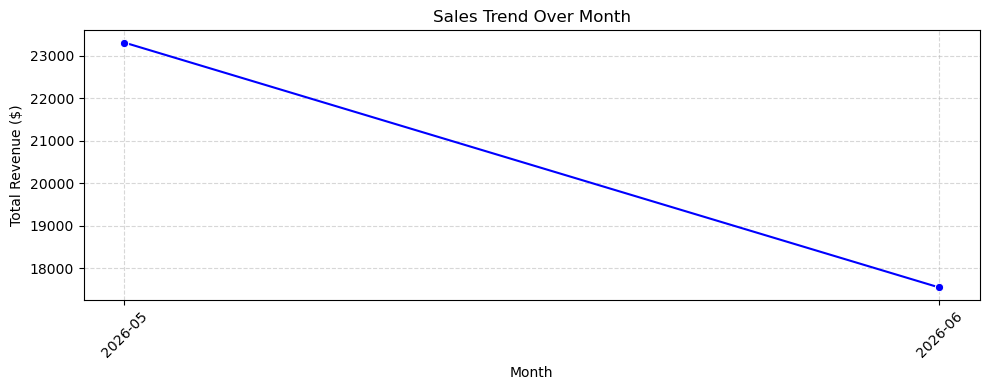

In [67]:
# Convert SaleDate to datetime and create a Year-Month column
rs['SaleDate'] = pd.to_datetime(rs['SaleDate'])
rs['Month'] = rs['SaleDate'].dt.to_period('M').astype(str)

# Aggregate revenue by month
monthly_sales = rs.groupby('Month')['FinalPrice'].sum().reset_index()

# Plot line chart
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_sales, x='Month', y='FinalPrice', marker='o', color='b')
plt.title('Sales Trend Over Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

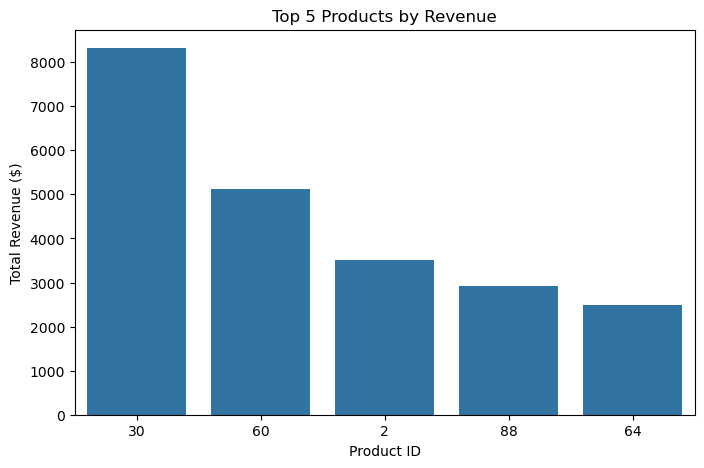

In [69]:
# Calculate total revenue per product and get top 5
top5_products = (
    rs.groupby('ProductID')['FinalPrice']
    .sum()
    .nlargest(5)
    .reset_index()
)

# Plot bar chart
plt.figure(figsize=(8, 5))
sns.barplot(
    data=top5_products,
    x='ProductID',
    y='FinalPrice',
    order=top5_products['ProductID'],
)
plt.title('Top 5 Products by Revenue')
plt.xlabel('Product ID')
plt.ylabel('Total Revenue ($)')
plt.show()

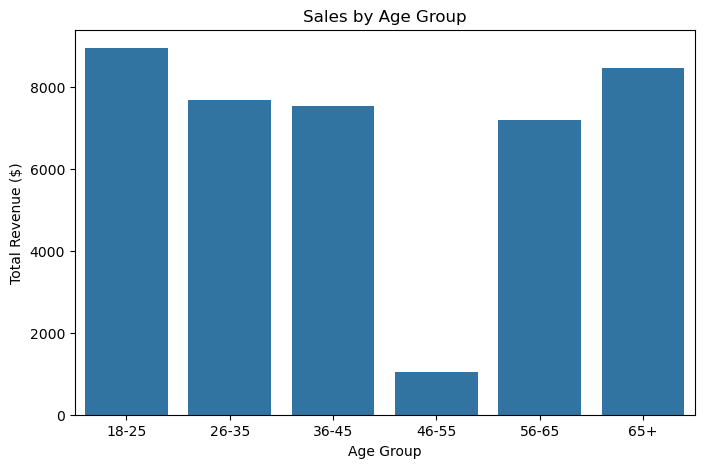

In [71]:
# Plot bar chart for revenue by age group
plt.figure(figsize=(8, 5))
sns.barplot( data=rs,x='AgeGroup',
    y='FinalPrice',
    estimator=sum,
    errorbar=None,
)
plt.title('Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue ($)')
plt.show()